In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv('exoplanet_data.csv', comment='#')

In [3]:
print("Shape:", data.shape)
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

print("\nColumn Titles:")
print(data.columns)

Shape: (567, 92)
Rows: 567
Columns: 92

Column Titles:
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr

No idea what the following column names mean: pl_orbpererr2, pl_eqt, pl_insol, ttv_flag, and st_met

- Planet Name (pl_name):
    - *Description*: Planet name most commonly used in the literature
    - *Interpretation*: Name the planet is referred to
- Host Name (hostname):
    - *Description*: Stellar name most commonly used in the literature
    - *Interpretation*: The star the planet is a host to
- Discovery Method (discoverymethod):
    - *Description*: Method by which the planet was first identified
    - *Interpretation*: Mthod by which the planet was first discovered
- Spectral Type (st_spectype):
    - *Description*: Classification of the star based on their spectral characteristics following the Morgan-Keenan system
    - *Interpretation*: The classification of the star spectral type (o, b, a, f, g, k, m, l, t, y)
- Equilibrium Temperature [K] (pl_eqt):
    - *Description*: The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
    - *Interpretation*: the temperature the planets surface equilizes to
- Planet Mass or Mass*sin(i) [Jupiter Mass] (pl_bmassj):
    - *Description*: Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses
    - *Interpretation*: mass of planet measured in Jupiter masses, taking into account the inclination

In [4]:
cols_to_keep = [
    'pl_name', 
    'hostname', 
    'discoverymethod',
    'st_spectype', 
    'pl_eqt', 
    'pl_bmassj'
]

data_subset = data[cols_to_keep]

data_subset = data_subset.dropna()

In [5]:
# Shape
print('Shape:', data_subset.shape)

# Rows and columns
print('Rows:', data_subset.shape[0])
print('Columns:', data_subset.shape[1])

# First five rows
print('\nFirst five rows:')
print(data_subset.head())

# Last five rows
print('\nLast five rows:')
print(data_subset.tail())

# Column titles
print("\nColumn Titles:")
print(list(data_subset.columns))

Shape: (67, 6)
Rows: 67
Columns: 6

First five rows:
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000

Last five rows:
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
546   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
549   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
561       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310

Column Titles:
['pl_name', 'hostname', 'discoverymethod', '

In [6]:
method_counts = data_subset['discoverymethod'].value_counts()

print("Discovery Methods:")
print(method_counts)
print(f"\nThere are {len(method_counts)} different discovery methods.\n")

most_common = method_counts.idxmax()
least_common = method_counts.idxmin()

print(f"Most common discovery method: {most_common} ({method_counts.max()} planets)")
print(f"Least common discovery method: {least_common} ({method_counts.min()} planets)")

Discovery Methods:
discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

There are 3 different discovery methods.

Most common discovery method: Transit (52 planets)
Least common discovery method: Imaging (2 planets)


- Transit — detects dips in starlight as a planet passes in front of its star.
- Radial Velocity — measures the wobble of a star due to the planet’s gravity.
- Imaging — directly takes pictures of exoplanets.

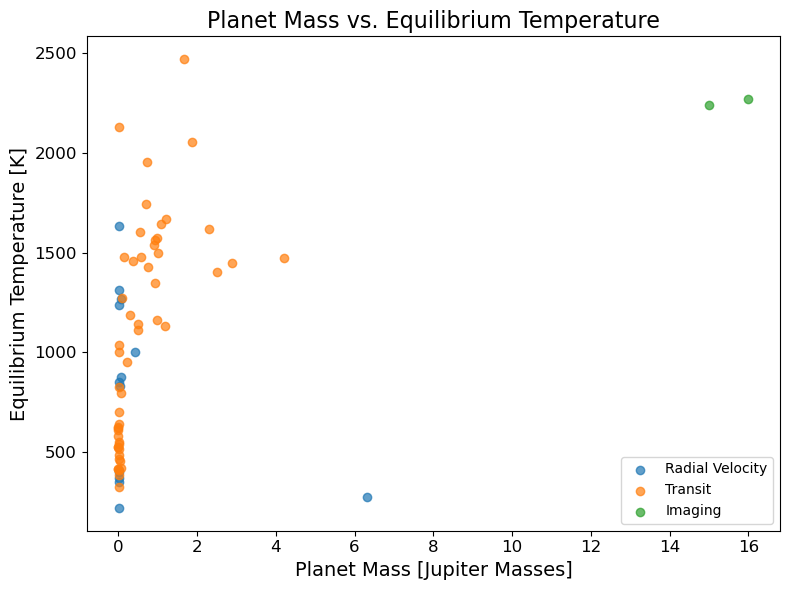

In [7]:
methods_list = data_subset['discoverymethod'].unique()

plt.figure(figsize=(8,6))
for method in methods_list:
    data_subset2 = data_subset[data_subset['discoverymethod'] == method]
    plt.scatter(data_subset2['pl_bmassj'], data_subset2['pl_eqt'], alpha=0.7, label=f'{method}')

plt.title('Planet Mass vs. Equilibrium Temperature', fontsize=16)
plt.xlabel('Planet Mass [Jupiter Masses]', fontsize=14)
plt.ylabel('Equilibrium Temperature [K]', fontsize=14)
plt.tick_params(labelsize=12)
plt.legend()
plt.tight_layout()
plt.show()

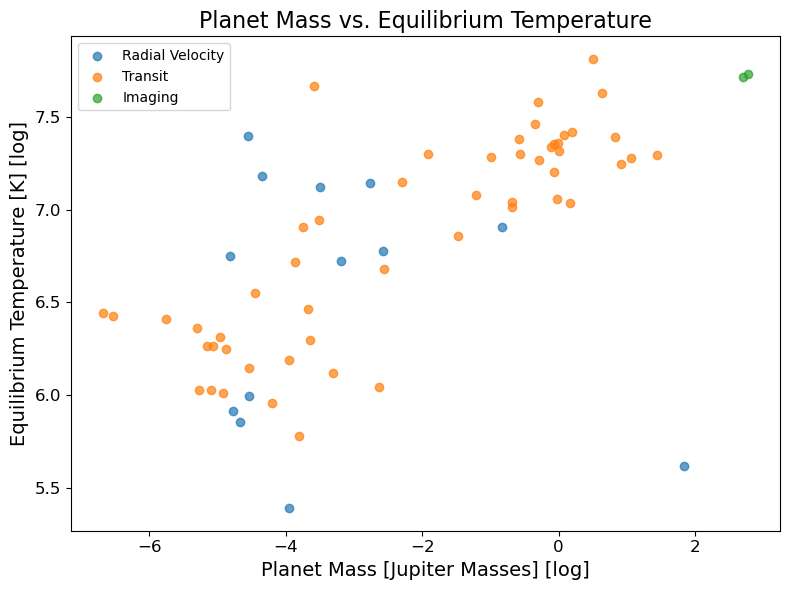

In [8]:
methods_list = data_subset['discoverymethod'].unique()

plt.figure(figsize=(8,6))
for method in methods_list:
    data_subset2 = data_subset[data_subset['discoverymethod'] == method]
    plt.scatter(np.log(data_subset2['pl_bmassj']), np.log(data_subset2['pl_eqt']), alpha=0.7, label=f'{method}')

plt.title('Planet Mass vs. Equilibrium Temperature', fontsize=16)
plt.xlabel('Planet Mass [Jupiter Masses] [log]', fontsize=14)
plt.ylabel('Equilibrium Temperature [K] [log]', fontsize=14)
plt.tick_params(labelsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Exoplanets found by the imaging method more likely to be massive

In [9]:
massive_planets = data_subset[data_subset['pl_bmassj'] > 5]
coldest_planet = massive_planets.loc[massive_planets['pl_eqt'].idxmin()]

print(f"Name: {coldest_planet['pl_name']}")
print(f"\nIndex: {coldest_planet.name}")
print(f"\nEquilibrium Temp: {coldest_planet['pl_eqt']} K")
print(f"\nMass: {coldest_planet['pl_bmassj']} Jupiter masses")
print(f"\nHost Star Spectral Type: {coldest_planet['st_spectype']}")


Name: eps Ind A b

Index: 566

Equilibrium Temp: 275.0 K

Mass: 6.31 Jupiter masses

Host Star Spectral Type: K5 V


The host star’s spectral type can be compared to the Sun’s (which is G2V). So, we can see they are different.

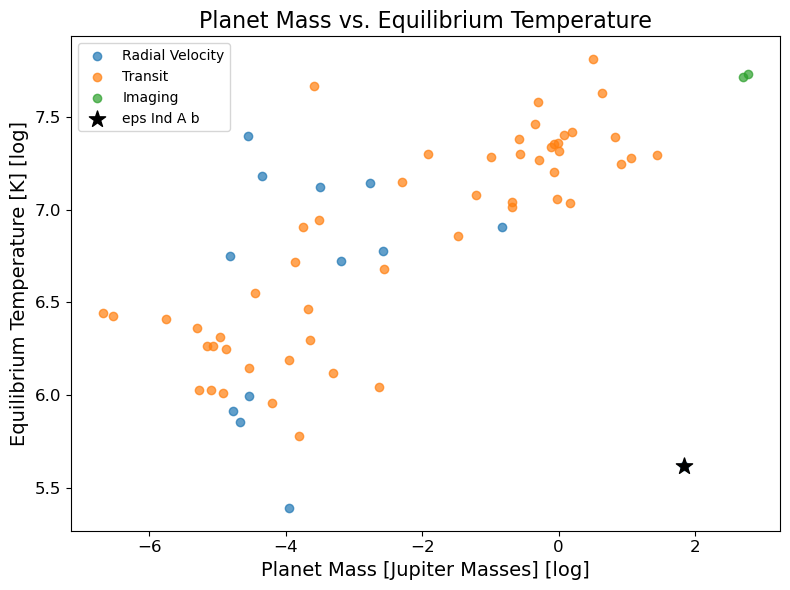

In [10]:
methods_list = data_subset['discoverymethod'].unique()

plt.figure(figsize=(8,6))
for method in methods_list:
    data_subset2 = data_subset[data_subset['discoverymethod'] == method]
    plt.scatter(np.log(data_subset2['pl_bmassj']), np.log(data_subset2['pl_eqt']), alpha=0.7, label=f'{method}')
plt.scatter(np.log(coldest_planet['pl_bmassj']), np.log(coldest_planet['pl_eqt']),color='black', marker='*', 
            s=150, label=f'{coldest_planet['pl_name']}')
plt.title('Planet Mass vs. Equilibrium Temperature', fontsize=16)
plt.xlabel('Planet Mass [Jupiter Masses] [log]', fontsize=14)
plt.ylabel('Equilibrium Temperature [K] [log]', fontsize=14)
plt.tick_params(labelsize=12)
plt.legend()
plt.tight_layout()
plt.show()

__Nature Paper__
- What is the title of this paper?
    - "A temperate super-Jupiter imaged with JWST in the mid-infrared"
- Summarize the abstract to the best of your ability in your own words.
    - There is a giant planet orbitting a K5V type star roughly 3.6384 ± 0.0013 pc away. Based on JWST coronagraphic images measurements of radial and astrometric measurements are consistent, but not the planet's properties. The giant planet has a temperature of approximately 275 K and a brightness of 10.65 and 15.50 µm. There is likely an unknown opacity source in the atmosphere due non-detections between 3.5 and 5.0 µm. These could possibly suggest a high-metallicity, high carbon-to-oxygen ratio planet. The planet's temperature is consistent with the theoretical thermal evolution model, which were previously untested at this temperature range. Based on the data, this is likely the only giant planet in the system, so we refer to it as b, despite it having significantly different orbital properties than the previously claimed planet b.
- Does your answer match the exoplanet?
    - Yes, the planet I have as the coldest above 5 Jupiter masses matches the paper's listed properties.
- What is special about the planet you found?
    - This planet is the coldest directly imaged gas giant ever detected. It shows that JWST can detect massive exoplanets at much lower temperatures than was previously thought possible, extending the range of direct imaging to cooler, older systems. Its atmosphere also appears to have unusual chemistry, which challenges existing models of gas giant formation and evolution.
- Do the mass and equilibrium temperature match what the paper reported? If not, what
are the differences?
    - The mass and equilibrium temperature match what the paper reported.